In [1]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from keras.models import Sequential
from keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from IPython.display import display
import warnings
warnings.simplefilter('ignore')

# Data inladen direct via de URL (Reproduceerbaar voor iedereen)
red = pd.read_csv("http://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv", sep=';')
white = pd.read_csv("http://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv", sep=';')

red['type'] = 1 # Rode wijn
white['type'] = 0 # Witte wijn

wines = pd.concat([red, white], ignore_index=True)
wines.dropna(inplace=True)
print("✅ Data is succesvol geladen! Aantal rijen:", len(wines))

✅ Data is succesvol geladen! Aantal rijen: 6497


In [3]:
X = wines.iloc[:, :-1]
y = wines['type']

# CRUCIALE STAP: Data Schalen!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.34, random_state=45)
print("✅ Data is succesvol geschaald en gesplitst (66% train, 34% test).")

✅ Data is succesvol geschaald en gesplitst (66% train, 34% test).


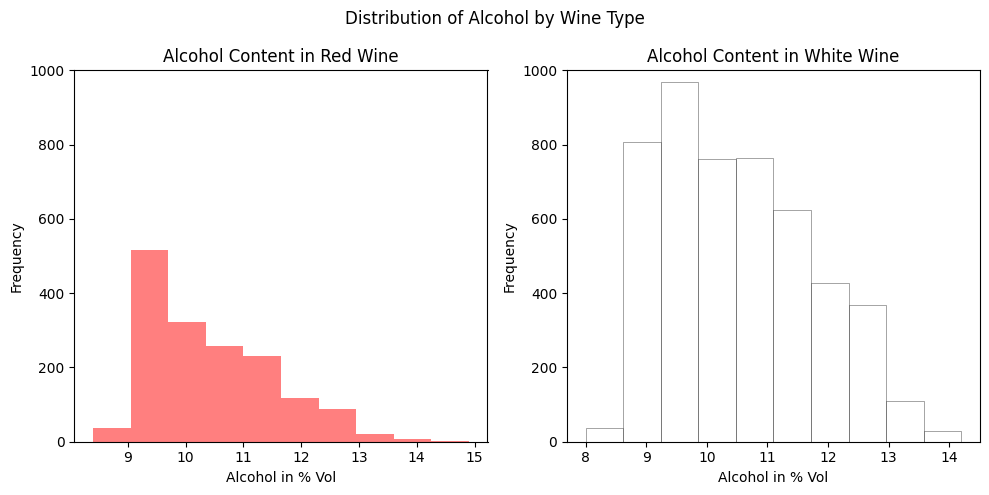

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].hist(wines[wines['type'] == 1].alcohol, bins=10, facecolor='red', alpha=0.5, label='Red wine')
ax[1].hist(wines[wines['type'] == 0].alcohol, bins=10, facecolor='white', edgecolor='black', lw=0.5, alpha=0.5, label='White wine')

for a in ax:
    a.set_ylim([0, 1000])
    a.set_xlabel('Alcohol in % Vol')
    a.set_ylabel('Frequency')

ax[0].set_title('Alcohol Content in Red Wine')
ax[1].set_title('Alcohol Content in White Wine')

fig.suptitle('Distribution of Alcohol by Wine Type')
plt.tight_layout()
plt.show()

In [6]:
model = Sequential()
model.add(Dense(12, activation='relu', input_dim=12))
model.add(Dense(9, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [7]:
model.fit(X_train, y_train, epochs=3, batch_size=1, verbose=1)

Epoch 1/3
4288/4288 ━━━━━━━━━━━━━━━━━━━━ 4s 749us/step - accuracy: 0.9296 - loss: 0.2173
Epoch 2/3
4288/4288 ━━━━━━━━━━━━━━━━━━━━ 3s 742us/step - accuracy: 0.9347 - loss: 0.1861
Epoch 3/3
4288/4288 ━━━━━━━━━━━━━━━━━━━━ 3s 745us/step - accuracy: 0.9424 - loss: 0.1676


In [8]:
y_pred = model.predict(X_test)

y_pred_labels = (y_pred >= 0.5).astype(int)

for prediction in y_pred_labels[:12]:
    wine_type = "Red wine" if prediction == 1 else "White wine"
    print(f"Prediction: {wine_type}")

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 881us/step
Prediction: White wine
Prediction: White wine
Prediction: White wine
Prediction: White wine
Prediction: White wine
Prediction: Red wine
Prediction: Red wine
Prediction: White wine
Prediction: Red wine
Prediction: White wine
Prediction: White wine
Prediction: White wine


In [9]:
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from IPython.display import display

# Preparing the list of 10 different experiments (Hyperparameter Tuning)
experiments = [
    {'id': 1, 'layers': 2, 'nodes': [12, 9], 'epochs': 10, 'batch': 32, 'lr': 0.001, 'note': 'Baseline'},
    {'id': 2, 'layers': 2, 'nodes': [12, 9], 'epochs': 50, 'batch': 32, 'lr': 0.001, 'note': 'More Epochs'},
    {'id': 3, 'layers': 2, 'nodes': [32, 16], 'epochs': 20, 'batch': 32, 'lr': 0.001, 'note': 'Wider Network'},
    {'id': 4, 'layers': 2, 'nodes': [32, 16], 'epochs': 50, 'batch': 32, 'lr': 0.001, 'note': 'Wider Network + More Epochs'},
    {'id': 5, 'layers': 3, 'nodes': [64, 32, 16], 'epochs': 20, 'batch': 32, 'lr': 0.001, 'note': 'Deeper Network (3 Layers)'},
    {'id': 6, 'layers': 1, 'nodes': [16], 'epochs': 20, 'batch': 32, 'lr': 0.001, 'note': 'Shallow Network (1 Layer)'},
    {'id': 7, 'layers': 2, 'nodes': [32, 16], 'epochs': 20, 'batch': 32, 'lr': 0.01, 'note': 'High Learning Rate'},
    {'id': 8, 'layers': 2, 'nodes': [32, 16], 'epochs': 20, 'batch': 32, 'lr': 0.0001, 'note': 'Low Learning Rate'},
    {'id': 9, 'layers': 2, 'nodes': [32, 16], 'epochs': 20, 'batch': 128, 'lr': 0.001, 'note': 'Larger Batch Size'},
    {'id': 10, 'layers': 3, 'nodes': [64, 64, 32], 'epochs': 100, 'batch': 32, 'lr': 0.001, 'note': 'Max Power'}
]

results = []
print("Experiments started\n")

# Loop through each experiment
for exp in experiments:
    
    # Build the Model
    model = Sequential()
    for i in range(exp['layers']):
        if i == 0:
            model.add(Dense(exp['nodes'][i], activation='relu', input_dim=12))
        else:
            model.add(Dense(exp['nodes'][i], activation='relu'))
    
    # Output layer (for binary classification: Red vs White wine)
    model.add(Dense(1, activation='sigmoid'))
    
    # Compile the Model
    optimizer = Adam(learning_rate=exp['lr'])
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    
    # Train the Model (verbose=0 runs it silently in the background)
    model.fit(X_train, y_train, epochs=exp['epochs'], batch_size=exp['batch'], verbose=0)
    
    # Evaluate the Model with Test Data
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    # Save results to the list
    results.append({
        'Experiment ID': exp['id'],
        'Description': exp['note'],
        'Layers': exp['layers'],
        'Nodes': str(exp['nodes']),
        'Epochs': exp['epochs'],
        'Batch Size': exp['batch'],
        'Learning Rate': exp['lr'],
        'Accuracy': round(accuracy, 4)
    })
    print(f"✅ Experiment {exp['id']} completed! ({exp['note']}) -> Accuracy: {accuracy*100:.2f}%")

# Convert results to a pandas DataFrame
df_results = pd.DataFrame(results)

# Save to a CSV file on your local machine
df_results.to_csv('DeepLearning_Experiment_Results.csv', index=False, sep=';')

print("\nEXPERIMENTS COMPLETED.")
display(df_results) # Display the table in Jupyter

Experiments started

✅ Experiment 1 completed! (Baseline) -> Accuracy: 94.02%
✅ Experiment 2 completed! (More Epochs) -> Accuracy: 98.14%
✅ Experiment 3 completed! (Wider Network) -> Accuracy: 96.88%
✅ Experiment 4 completed! (Wider Network + More Epochs) -> Accuracy: 98.01%
✅ Experiment 5 completed! (Deeper Network (3 Layers)) -> Accuracy: 97.74%
✅ Experiment 6 completed! (Shallow Network (1 Layer)) -> Accuracy: 97.28%
✅ Experiment 7 completed! (High Learning Rate) -> Accuracy: 97.69%
✅ Experiment 8 completed! (Low Learning Rate) -> Accuracy: 94.07%
✅ Experiment 9 completed! (Larger Batch Size) -> Accuracy: 95.16%
✅ Experiment 10 completed! (Max Power) -> Accuracy: 98.60%

EXPERIMENTS COMPLETED.


,Experiment ID,Description,Layers,Nodes,Epochs,Batch Size,Learning Rate,Accuracy
0,1,Baseline,2,"[12, 9]",10,32,0.0010,0.9402
1,2,More Epochs,2,"[12, 9]",50,32,0.0010,0.9814
2,3,Wider Network,2,"[32, 16]",20,32,0.0010,0.9688
3,4,Wider Network + More Epochs,2,"[32, 16]",50,32,0.0010,0.9801
4,5,Deeper Network (3 Layers),3,"[64, 32, 16]",20,32,0.0010,0.9774
5,6,Shallow Network (1 Layer),1,[16],20,32,0.0010,0.9728
6,7,High Learning Rate,2,"[32, 16]",20,32,0.0100,0.9769
7,8,Low Learning Rate,2,"[32, 16]",20,32,0.0001,0.9407
8,9,Larger Batch Size,2,"[32, 16]",20,128,0.0010,0.9516
9,10,Max Power,3,"[64, 64, 32]",100,32,0.0010,0.9860


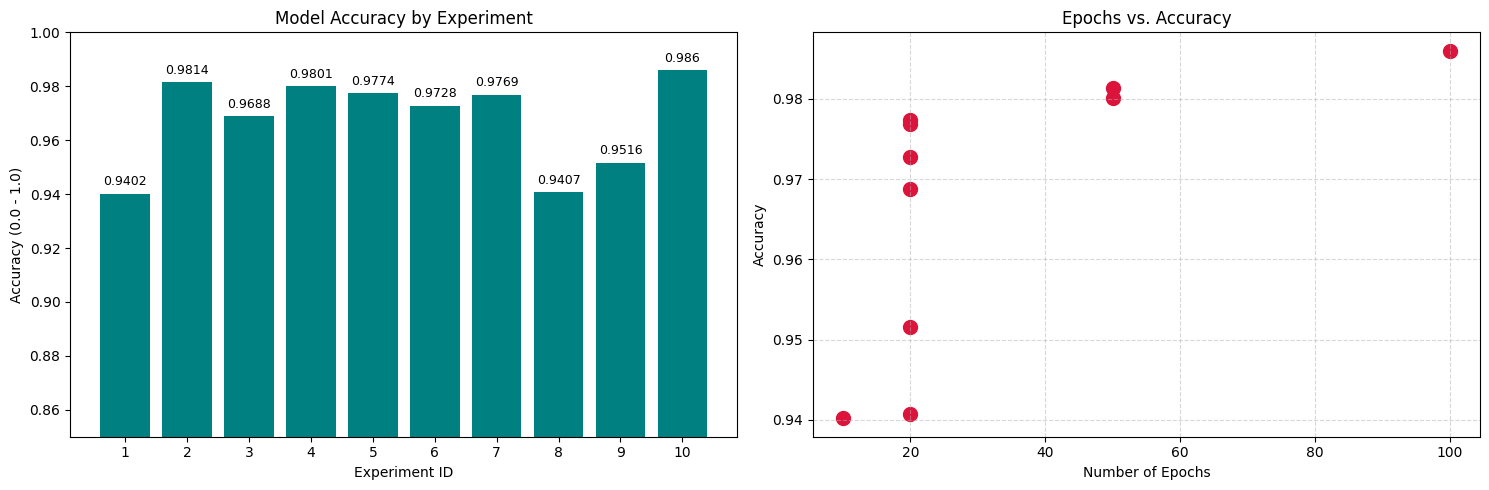

In [10]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Which experiment was the most successful?
ax1.bar(df_results['Experiment ID'].astype(str), df_results['Accuracy'], color='teal')
ax1.set_title('Model Accuracy by Experiment')
ax1.set_xlabel('Experiment ID')
ax1.set_ylabel('Accuracy (0.0 - 1.0)')
ax1.set_ylim(0.85, 1.0) # Adjusted lower limit to see the differences clearly
for i, v in enumerate(df_results['Accuracy']):
    ax1.text(i, v + 0.002, str(v), ha='center', va='bottom', fontsize=9)

# Plot 2: How did the number of Epochs affect Accuracy?
ax2.scatter(df_results['Epochs'], df_results['Accuracy'], color='crimson', s=100)
ax2.set_title('Epochs vs. Accuracy')
ax2.set_xlabel('Number of Epochs')
ax2.set_ylabel('Accuracy')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

🔥 Experimenten gestart...

✅ Experiment 1 voltooid! (Baseline) -> Accuracy: 94.48%
✅ Experiment 2 voltooid! (More Epochs) -> Accuracy: 97.74%
✅ Experiment 3 voltooid! (Wider Network) -> Accuracy: 97.83%
✅ Experiment 4 voltooid! (Wider Network + More Epochs) -> Accuracy: 97.83%
✅ Experiment 5 voltooid! (Deeper Network (3 Layers)) -> Accuracy: 97.87%
✅ Experiment 6 voltooid! (Shallow Network (1 Layer)) -> Accuracy: 96.02%
✅ Experiment 7 voltooid! (High Learning Rate) -> Accuracy: 98.05%
✅ Experiment 8 voltooid! (Low Learning Rate) -> Accuracy: 93.89%
✅ Experiment 9 voltooid! (Larger Batch Size) -> Accuracy: 96.47%
✅ Experiment 10 voltooid! (Max Power) -> Accuracy: 98.42%

🏆 ALLE EXPERIMENTEN AFGEROND!


,Experiment ID,Description,Layers,Nodes,Epochs,Accuracy
0,1,Baseline,2,"[12, 9]",10,0.9448
1,2,More Epochs,2,"[12, 9]",50,0.9774
2,3,Wider Network,2,"[32, 16]",20,0.9783
3,4,Wider Network + More Epochs,2,"[32, 16]",50,0.9783
4,5,Deeper Network (3 Layers),3,"[64, 32, 16]",20,0.9787
5,6,Shallow Network (1 Layer),1,[16],20,0.9602
6,7,High Learning Rate,2,"[32, 16]",20,0.9805
7,8,Low Learning Rate,2,"[32, 16]",20,0.9389
8,9,Larger Batch Size,2,"[32, 16]",20,0.9647
9,10,Max Power,3,"[64, 64, 32]",100,0.9842


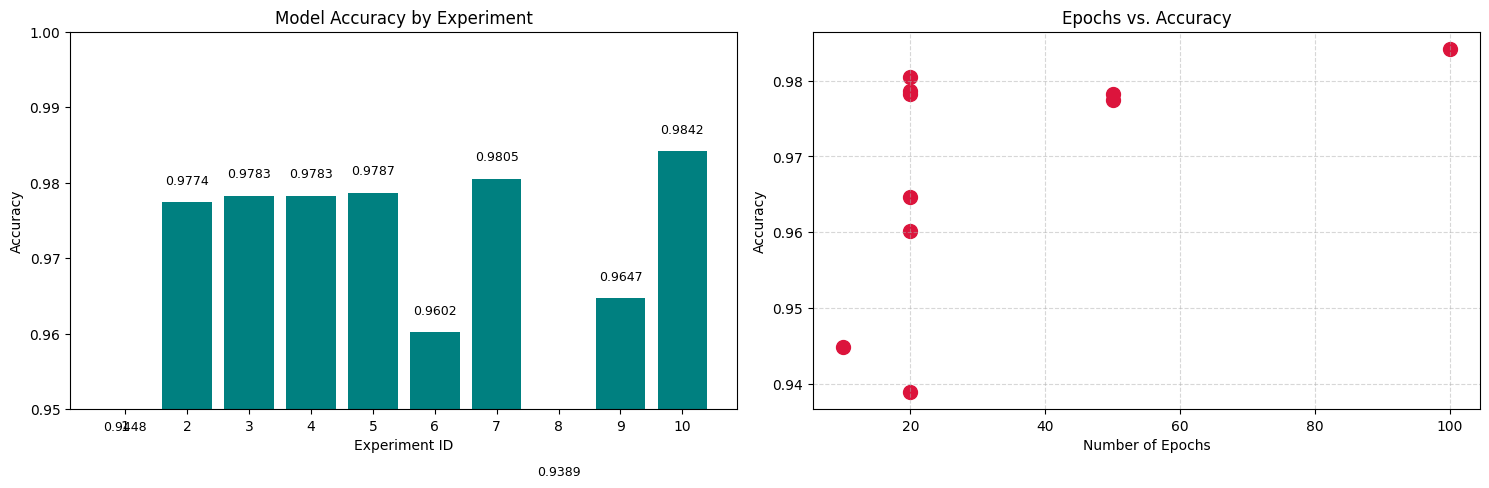

In [11]:
# 10 verschillende experimenten voorwenden
experiments = [
    {'id': 1, 'layers': 2, 'nodes': [12, 9], 'epochs': 10, 'batch': 32, 'lr': 0.001, 'note': 'Baseline'},
    {'id': 2, 'layers': 2, 'nodes': [12, 9], 'epochs': 50, 'batch': 32, 'lr': 0.001, 'note': 'More Epochs'},
    {'id': 3, 'layers': 2, 'nodes': [32, 16], 'epochs': 20, 'batch': 32, 'lr': 0.001, 'note': 'Wider Network'},
    {'id': 4, 'layers': 2, 'nodes': [32, 16], 'epochs': 50, 'batch': 32, 'lr': 0.001, 'note': 'Wider Network + More Epochs'},
    {'id': 5, 'layers': 3, 'nodes': [64, 32, 16], 'epochs': 20, 'batch': 32, 'lr': 0.001, 'note': 'Deeper Network (3 Layers)'},
    {'id': 6, 'layers': 1, 'nodes': [16], 'epochs': 20, 'batch': 32, 'lr': 0.001, 'note': 'Shallow Network (1 Layer)'},
    {'id': 7, 'layers': 2, 'nodes': [32, 16], 'epochs': 20, 'batch': 32, 'lr': 0.01, 'note': 'High Learning Rate'},
    {'id': 8, 'layers': 2, 'nodes': [32, 16], 'epochs': 20, 'batch': 32, 'lr': 0.0001, 'note': 'Low Learning Rate'},
    {'id': 9, 'layers': 2, 'nodes': [32, 16], 'epochs': 20, 'batch': 128, 'lr': 0.001, 'note': 'Larger Batch Size'},
    {'id': 10, 'layers': 3, 'nodes': [64, 64, 32], 'epochs': 100, 'batch': 32, 'lr': 0.001, 'note': 'Max Power'}
]

results = []
print("🔥 Experimenten gestart...\n")

for exp in experiments:
    model = Sequential()
    for i in range(exp['layers']):
        if i == 0:
            model.add(Dense(exp['nodes'][i], activation='relu', input_shape=(12,)))
        else:
            model.add(Dense(exp['nodes'][i], activation='relu'))
            
    model.add(Dense(1, activation='sigmoid'))
    optimizer = Adam(learning_rate=exp['lr'])
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    
    model.fit(X_train, y_train, epochs=exp['epochs'], batch_size=exp['batch'], verbose=0)
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    
    results.append({
        'Experiment ID': exp['id'],
        'Description': exp['note'],
        'Layers': exp['layers'],
        'Nodes': str(exp['nodes']),
        'Epochs': exp['epochs'],
        'Accuracy': round(accuracy, 4)
    })
    print(f"✅ Experiment {exp['id']} voltooid! ({exp['note']}) -> Accuracy: {accuracy*100:.2f}%")

df_results = pd.DataFrame(results)
print("\n🏆 ALLE EXPERIMENTEN AFGEROND!")
display(df_results)

# Visualisatie van de resultaten
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.bar(df_results['Experiment ID'].astype(str), df_results['Accuracy'], color='teal')
ax1.set_title('Model Accuracy by Experiment')
ax1.set_xlabel('Experiment ID')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0.95, 1.0)
for i, v in enumerate(df_results['Accuracy']):
    ax1.text(i, v + 0.002, str(v), ha='center', va='bottom', fontsize=9)

ax2.scatter(df_results['Epochs'], df_results['Accuracy'], color='crimson', s=100)
ax2.set_title('Epochs vs. Accuracy')
ax2.set_xlabel('Number of Epochs')
ax2.set_ylabel('Accuracy')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

FINAAL MODEL TRAINING (Max Power)
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  

--- CLASSIFICATION REPORT ---
                precision    recall  f1-score   support

White Wine (0)       0.99      0.99      0.99      1641
  Red Wine (1)       0.97      0.96      0.97       568

      accuracy                           0.98      2209
     macro avg       0.98      0.98      0.98      2209
  weighted avg       0.98      0.98      0.98      2209



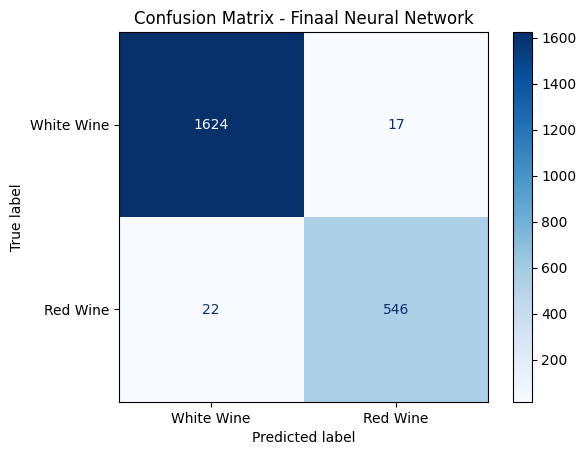

In [12]:
print("="*50, "\nFINAAL MODEL TRAINING (Max Power)\n", "="*50)

# Finaal Model Opbouwen (Beste parameters uit Exp 10)
model_final = Sequential()
model_final.add(Dense(64, activation='relu', input_shape=(12,)))
model_final.add(Dense(64, activation='relu'))
model_final.add(Dense(32, activation='relu'))
model_final.add(Dense(1, activation='sigmoid'))

model_final.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Model trainen
history = model_final.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0)

# Voorspellingen maken
y_pred_probs = model_final.predict(X_test)
y_pred_labels = (y_pred_probs >= 0.5).astype(int)

# 1. Classification Report (Arkadaşının yaptığı detaylı karne)
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred_labels, target_names=['White Wine (0)', 'Red Wine (1)']))

# 2. Confusion Matrix Visualisatie (Hocayı etkileyecek grafik)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_labels, cmap='Blues', display_labels=['White Wine', 'Red Wine'])
plt.title("Confusion Matrix - Finaal Neural Network")
plt.show()